https://www.kaggle.com/datasets/nikhil7280/weather-type-classification

In [ ]:
#import the libraries needed
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [ ]:
#Load the weather classification data set
weather = pd.read_csv('weather_classification_data.csv')

In [ ]:
#display information from the dataset
#shows rows, feature columns, and names of the feature.
print(weather.head())



   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  Spring              1.0   coastal   
4                990.67         1  Winter              2.5  mountain   

  Weather Type  
0        Rainy  
1       Cloudy  
2        Sunny  
3        Sunny  
4        Rainy  


In [ ]:
#Using feature engineering convert text columns to numeric values
le = LabelEncoder()
label = le.fit_transform(weather['Cloud Cover'])
weather.drop('Cloud Cover', axis=1, inplace=True)
weather['Cloud Cover'] = label


In [ ]:
#Using feature engineering convert text columns to numeric values
le = LabelEncoder()
label = le.fit_transform(weather['Season'])
weather.drop('Season', axis=1, inplace=True)
weather['Season'] = label

In [ ]:
#Using feature engineering convert text columns to numeric values
le = LabelEncoder()
label = le.fit_transform(weather['Location'])
weather.drop('Location', axis=1, inplace=True)
weather['Location'] = label

In [ ]:
#Using feature engineering convert text columns to numeric values
le = LabelEncoder()
label = le.fit_transform(weather['Weather Type'])
weather.drop('Weather Type', axis=1, inplace=True)
weather['Weather Type'] = label

In [ ]:
print(weather.head())

   Temperature  Humidity  Wind Speed  Precipitation (%)  Atmospheric Pressure  \
0         14.0        73         9.5               82.0               1010.82   
1         39.0        96         8.5               71.0               1011.43   
2         30.0        64         7.0               16.0               1018.72   
3         38.0        83         1.5               82.0               1026.25   
4         27.0        74        17.0               66.0                990.67   

   UV Index  Visibility (km)  Cloud Cover  Season  Location  Weather Type  
0         2              3.5            3       3         1             1  
1         7             10.0            3       1         1             0  
2         5              5.5            0       1         2             3  
3         7              1.0            0       1         0             3  
4         1              2.5            2       3         2             1  


In [ ]:
#create x as the feature column and y as the target column
#Check how many samples belong to each weather class
X = weather.iloc[:, 0:10]
y = weather.iloc[:, 10]

print("\n" + "=" * 60)
print("Class Distribution")
print("=" * 60)
print(np.unique(y, return_counts=True))


Class Distribution
(array([0, 1, 2, 3]), array([3300, 3300, 3300, 3300]))


In [ ]:
#Split the data set into training and testing sets
#Print the size of the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


TRAIN/TEST SPLIT
Training set size: 9240 samples
Testing set size: 3960 samples


In [ ]:
#Standardize the feature values before training the model
#check the mean before and after scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nBefore scaling - Temperature mean: {X_train['Temperature'].mean():.2f}")
print(f"After scaling  - Temperature mean: {X_train_scaled[:, 0].mean():.4f}")
print("(Should be approximately 0 after standardization)")


Before scaling - Temperature mean: 19.12
After scaling  - Temperature mean: -0.0000
(Should be approximately 0 after standardization)


In [ ]:
#Create the multinomial logistic regression model
#train the model
#print the information about the trained model
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    C=1.0,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("\n" + "=" * 60)
print("MODEL TRAINING COMPLETE")
print("=" * 60)
print(f"Number of iterations used: {model.n_iter_[0]}")
print(f"Coefficients shape: {model.coef_.shape}")
print("(One row of coefficients per class)")


MODEL TRAINING COMPLETE
Number of iterations used: 15
Coefficients shape: (4, 10)
(One row of coefficients per class)


In [ ]:
#Make predictions on the test data
#print the first 5 predictions and their probabilities
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

print("\n" + "=" * 60)
print("PREDICTIONS (First 5 Test Samples)")
print("=" * 60)

for i in range(5):
  print(f"Sample {i+1}: Actual={y_test.iloc[i]}, "
    f"Predicted={y_pred[i]}, "
    f"Probabilities={y_proba[i]}")


PREDICTIONS (First 5 Test Samples)
Sample 1: Actual=1, Predicted=1, Probabilities=[0.12354433 0.64994648 0.21733512 0.00917407]
Sample 2: Actual=3, Predicted=3, Probabilities=[2.52839943e-01 5.44515846e-03 2.08470167e-04 7.41506428e-01]
Sample 3: Actual=1, Predicted=3, Probabilities=[0.16635042 0.01994594 0.00120097 0.81250266]
Sample 4: Actual=1, Predicted=1, Probabilities=[0.2929485  0.57720306 0.08684987 0.04299858]
Sample 5: Actual=2, Predicted=2, Probabilities=[3.53667111e-02 6.37949392e-02 8.99950316e-01 8.88034016e-04]


In [ ]:
#calculate the accuracy of the model
#create the confusion matrix, compare actual and predicted
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

cm = confusion_matrix(
    y_test, y_pred
)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))


MODEL EVALUATION
Overall Accuracy: 0.8558 (85.6%)

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       990
           1       0.85      0.86      0.86       990
           2       0.90      0.92      0.91       990
           3       0.87      0.81      0.84       990

    accuracy                           0.86      3960
   macro avg       0.86      0.86      0.86      3960
weighted avg       0.86      0.86      0.86      3960



In [ ]:
#Store the model coeeficients in a dataframe.
#Print the top 3 most import features for each class
print("=" * 60)
print("FEATURE IMPORTANCE (Top 3 per class)")
print("=" *60)
coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns
)

for class_name in range(len(coef_df)):
  top_features = coef_df.loc[class_name].abs().nlargest(3)
  print(f"\n class_{class_name}:")
  for feat, val in top_features.items():
    actual_val = coef_df.loc[class_name, feat]
    direction = "↑ increases" if actual_val > 0 else "↓ decreases"
    print(f"   {feat}: {actual_val:.3f} ({direction} probability)")

print("\n" + "=" * 60)
print("DONE! Weather classification complete.")
print("=" * 60)

FEATURE IMPORTANCE (Top 3 per class)

 class_0:
   Cloud Cover: 0.601 (↑ increases probability)
   Precipitation (%): -0.580 (↓ decreases probability)
   Visibility (km): 0.480 (↑ increases probability)

 class_1:
   Precipitation (%): 0.802 (↑ increases probability)
   Visibility (km): -0.545 (↓ decreases probability)
   UV Index: -0.542 (↓ decreases probability)

 class_2:
   Temperature: -2.091 (↓ decreases probability)
   Season: 1.045 (↑ increases probability)
   Precipitation (%): 0.675 (↑ increases probability)

 class_3:
   Temperature: 1.308 (↑ increases probability)
   UV Index: 0.993 (↑ increases probability)
   Precipitation (%): -0.897 (↓ decreases probability)

DONE! Weather classification complete.


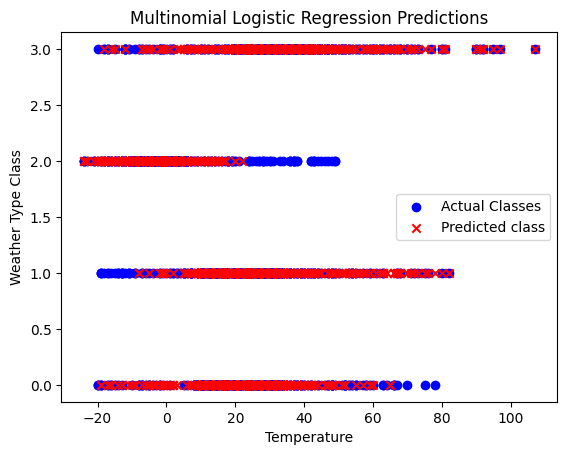

In [ ]:
#this graph compares the weather class to the classes predicted by the model using temperature as the feature.
#Blue dots represent the actual class value from the dataset. The red X represent the models predictions.
import matplotlib.pyplot as plt

plt.scatter(X_test['Temperature'], y_test, color='blue', label='Actual Classes')
plt.scatter(X_test['Temperature'], y_pred, color='red', marker='x', label='Predicted class')
plt.xlabel('Temperature')
plt.ylabel('Weather Type Class')
plt.title('Multinomial Logistic Regression Predictions')
plt.legend()
plt.show()

Mulitnomial logistic regression model was used to classify different weather types using the weather dataset. Features like temperature, humidity, wind speed, etc. Some values were text so they were converted to numeric values. The data was then split into a training and testing set, the model was trained to identify patterns between the weather features and the weather type.After training, predictions were made on the test data.